Exercises:

- E01: Tune the hyperparameters of the training to beat my best validation loss of 2.2
- E02: I was not careful with the intialization of the network in this video. (1) What is the loss you'd get if the predicted probabilities at initialization were perfectly uniform? What loss do we achieve? (2) Can you tune the initialization to get a starting loss that is much more similar to (1)?
- E03: Read the Bengio et al 2003 paper (link above), implement and try any idea from the paper. Did it work?


In [29]:
import torch.nn.functional as F
import torch
import random
import matplotlib.pyplot as plt

In [232]:
# GLOBAL VARAIBAL
block_size = 3 # 上下文长度
ch_dim = 10 # 每个字符的维度

In [31]:
words = open('../names.txt', 'r').read().splitlines()
random.shuffle(words)

In [32]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [233]:
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w:
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

# 拆分训练集
n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

In [244]:
# int parameter
# hide layer
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(27,ch_dim, generator=g)
neron_count = 200
hide_input = block_size * ch_dim
W1 = torch.randn(hide_input, neron_count, generator=g)
b1 = torch.randn(neron_count, generator=g)
# softmax
W2 = torch.randn(neron_count, 27, generator=g) # 27 outputs
b2 = torch.randn(27, generator=g)

parameters = [W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [118]:
lre = torch.linspace(-3,0,1000)
lrs = 10 ** lre

In [245]:
lri = []
lossi = []
stepi = []

In [246]:
g = torch.Generator().manual_seed(2147483647)
# train
for i in range(30000):
    # set loss rate
    # lr = lrs[i%10]
    lr = 0.1
    if (i > 20000):
        lr = 0.001
    # if (i > 8000):
    #     lr = 0.005
    # if (i > 15000):
    #     lr = 0.0005
    # lr = 0.08 if i >= 2000 else 0.005

    # minbactch
    ix = torch.randint(0, Xtr.shape[0], (32, )) # random select 32 inputs
    emb = C[Xtr[ix]] # 32,3,2

    # forward
    h = torch.tanh(emb.view(-1, hide_input) @ W1 + b1) # (32,6) @ (6, 100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    #backward
    for p in parameters:
        p.grad = None
    loss.backward()

    for p in parameters:
        p.data += - lr * p.grad

    stepi.append(i)
    lossi.append(loss.item())
    if (i % 1000 == 0):
        print(f'{i} - {loss.item()}')
    lri.append(lr)


0 - 25.66213607788086
1000 - 4.242190361022949
2000 - 3.3828275203704834
3000 - 3.2563483715057373
4000 - 3.209839105606079
5000 - 2.6041321754455566
6000 - 2.356525421142578
7000 - 2.6836674213409424
8000 - 2.7791666984558105
9000 - 2.7929868698120117
10000 - 1.7178593873977661
11000 - 2.3779549598693848
12000 - 2.411504030227661
13000 - 2.7235095500946045
14000 - 2.041790723800659
15000 - 2.1556010246276855
16000 - 2.063382625579834
17000 - 2.5569565296173096
18000 - 2.1425557136535645
19000 - 2.017749309539795
20000 - 2.2044801712036133
21000 - 2.396047353744507
22000 - 3.338833808898926
23000 - 2.58290958404541
24000 - 1.7762908935546875
25000 - 2.8051931858062744
26000 - 2.221472978591919
27000 - 1.9717274904251099
28000 - 2.177658796310425
29000 - 1.9355878829956055


In [247]:
# 当前参数在完整 train set 下的loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, hide_input) @ W1 + b1) # (32,6) @ (6, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2862, grad_fn=<NllLossBackward0>)

In [248]:
# 当前参数在 dev set 下的loss
emb = C[Xdev]
h = torch.tanh(emb.view(-1, hide_input) @ W1 + b1) # (32,6) @ (6, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3487, grad_fn=<NllLossBackward0>)

In [249]:
# 最后用 test set 验证实际的loss情况
emb = C[Xte]
h = torch.tanh(emb.view(-1, hide_input) @ W1 + b1) # (32,6) @ (6, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.3597, grad_fn=<NllLossBackward0>)

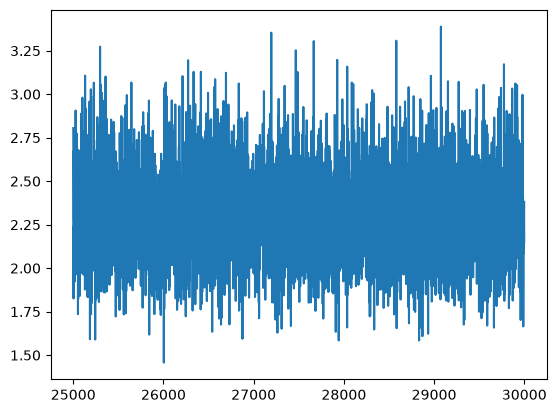

In [250]:
plt.plot(stepi[25000:30000], lossi[25000:30000])